In [10]:
import os
path1 = r"scripts/hubert_rep_extract.py"
print(os.path.exists(path1))

True


In [4]:
import os
print(os.getcwd())

/mnt/d/CODE/speechtokenier


采样率不同，已重采样预测音频：44100 → 16000
=== Audio Difference Analysis Results ===
采样率：16000 Hz
波形长度：825174 样本点
MSE（均方误差）：0.001047
MAE（平均绝对误差）：0.022435
SNR（信噪比）：-2.62 dB
余弦相似度（Cosine Similarity）：0.3110


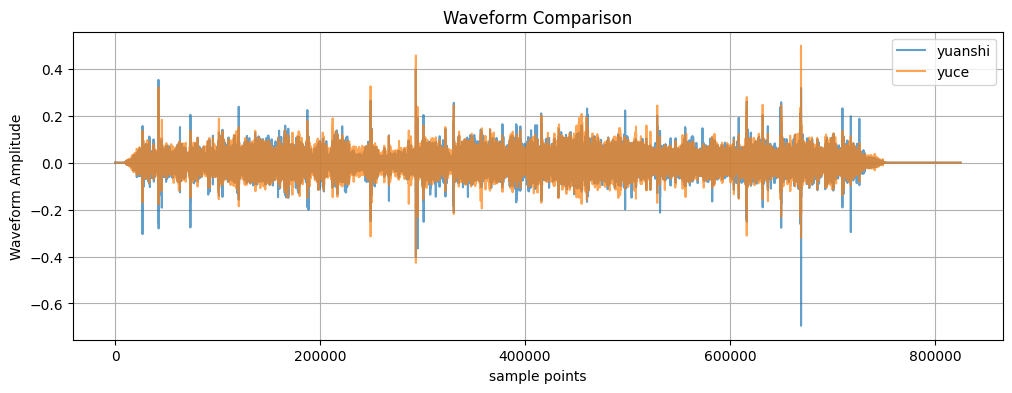

/home/baixian/speechtokenier/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/baixian/speechtokenier/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/baixian/speechtokenier/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/baixian/speechtokenier/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/baixian/speechtokenier/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: G

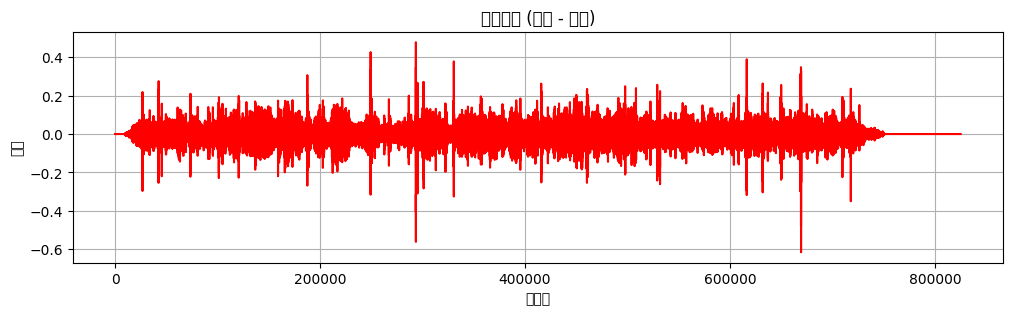

In [1]:
import torchaudio
import torch
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1️⃣ 指定两个音频文件路径
# =========================================================
ref_path = r"work_0-7.wav"      # 原始音频
pred_path = r"work.wav"    # 模型预测音频
# =========================================================
# 2️⃣ 加载音频文件
# =========================================================
ref_wave, ref_sr = torchaudio.load(ref_path)
pred_wave, pred_sr = torchaudio.load(pred_path)

# =========================================================
# 3️⃣ 对齐采样率与长度
# =========================================================
# 若采样率不同，则重采样
if ref_sr != pred_sr:
    print(f"采样率不同，已重采样预测音频：{pred_sr} → {ref_sr}")
    pred_wave = torchaudio.functional.resample(pred_wave, pred_sr, ref_sr)
    pred_sr = ref_sr

# 对齐长度（取最短）
min_len = min(ref_wave.shape[1], pred_wave.shape[1])
ref_wave = ref_wave[:, :min_len]
pred_wave = pred_wave[:, :min_len]

# =========================================================
# 4️⃣ 计算误差指标
# =========================================================
mse = torch.mean((ref_wave - pred_wave) ** 2).item()
mae = torch.mean(torch.abs(ref_wave - pred_wave)).item()

# 信噪比（SNR）
signal_power = torch.mean(ref_wave ** 2)
noise_power = torch.mean((ref_wave - pred_wave) ** 2)
snr = 10 * torch.log10(signal_power / noise_power)

# 余弦相似度
cos_sim = torch.nn.functional.cosine_similarity(ref_wave, pred_wave, dim=1).mean().item()

# =========================================================
# 5️⃣ 输出结果
# =========================================================
print("=== Audio Difference Analysis Results ===")
print(f"采样率：{ref_sr} Hz")
print(f"波形长度：{min_len} 样本点")
print(f"MSE（均方误差）：{mse:.6f}")
print(f"MAE（平均绝对误差）：{mae:.6f}")
print(f"SNR（信噪比）：{snr:.2f} dB")
print(f"余弦相似度（Cosine Similarity）：{cos_sim:.4f}")

# =========================================================
# 6️⃣ 可视化对比
# =========================================================
plt.figure(figsize=(12, 4))
plt.plot(ref_wave[0].numpy(), label="yuanshi", alpha=0.7)
plt.plot(pred_wave[0].numpy(), label="yuce", alpha=0.7)
plt.legend()
plt.title("Waveform Comparison")
plt.xlabel("sample points")
plt.ylabel("Waveform Amplitude")
plt.grid(True)
plt.show()

# 误差信号可视化
plt.figure(figsize=(12, 3))
plt.plot((ref_wave - pred_wave)[0].numpy(), color='r')
plt.title("误差信号 (原始 - 预测)")
plt.xlabel("样本点")
plt.ylabel("差值")
plt.grid(True)
plt.show()
